<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🟢 Adding 3 random blobs to image...


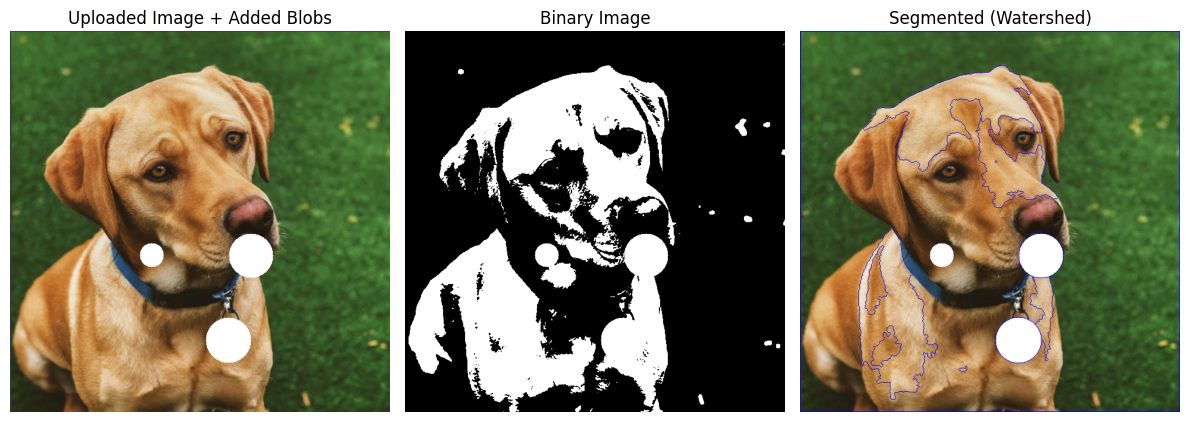

In [7]:
"""
watershed_segmentation_upload.py

Upload an image and segment small blobs using the Watershed Transform.
Also allows adding artificial blobs to the uploaded image.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog


# ---- Step 2: Add synthetic blobs ----
def add_blobs(img):
    h, w = img.shape[:2]
    blob_img = img.copy()

    print("\n🟢 Adding 3 random blobs to image...")
    for i in range(3):
        center = (np.random.randint(50, w-50), np.random.randint(50, h-50))
        radius = np.random.randint(20, 40)
        color = (255, 255, 255)
        cv2.circle(blob_img, center, radius, color, -1)

    return blob_img

# ---- Step 3: Apply watershed segmentation ----
def watershed_segmentation(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Apply watershed
    markers = cv2.watershed(img, markers)
    segmented = img.copy()
    segmented[markers == -1] = [255, 0, 0]  # red boundaries

    return binary, segmented

# ---- Step 4: Main Execution ----
if __name__ == "__main__":
    img = cv2.imread("/content/dog.png")
    blob_img = add_blobs(img)

    binary, segmented = watershed_segmentation(blob_img)

    # ---- Step 5: Display Results ----
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(blob_img, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image + Added Blobs")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(binary, cmap='gray')
    plt.title("Binary Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
    plt.title("Segmented (Watershed)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
